# EARA — Complete Conference Experiment

Reproducible notebook for the current Entropy-Aware Routing for Disorder Minimization experiment. The primary formulation is preserved; counterfactual and robustness tests are separated from the main result.


In [1]:
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
DATA_PATH = "twitter.txt"
print(f"Seed: {SEED}")


Seed: 42


## 1. Dataset and full graph


In [2]:
edges = pd.read_csv(DATA_PATH, sep=r"\s+", header=None, names=["source","target"], dtype=np.int64)
print(f"Rows: {len(edges):,}")
print(f"Missing values: {edges.isna().sum().sum()}")
print(f"Self-loops: {(edges.source == edges.target).sum():,}")
print(f"Duplicate rows: {edges.duplicated().sum():,}")
display(edges.head())

G = nx.Graph()
G.add_edges_from(edges[["source","target"]].itertuples(index=False, name=None))
degrees = np.array([d for _,d in G.degree()])
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Density: {nx.density(G):.8f}")
print(f"Mean degree: {degrees.mean():.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Max degree: {degrees.max():,}")
print(f"Connected components: {nx.number_connected_components(G):,}")


Rows: 2,420,766
Missing values: 0
Self-loops: 22
Duplicate rows: 652,617


,source,target
0,214328887,34428380
1,17116707,28465635
2,380580781,18996905
3,221036078,153460275
4,107830991,17868918


Nodes: 81,306
Edges: 1,342,310
Density: 0.00040611
Mean degree: 33.02
Median degree: 15.00
Max degree: 3,383
Connected components: 1


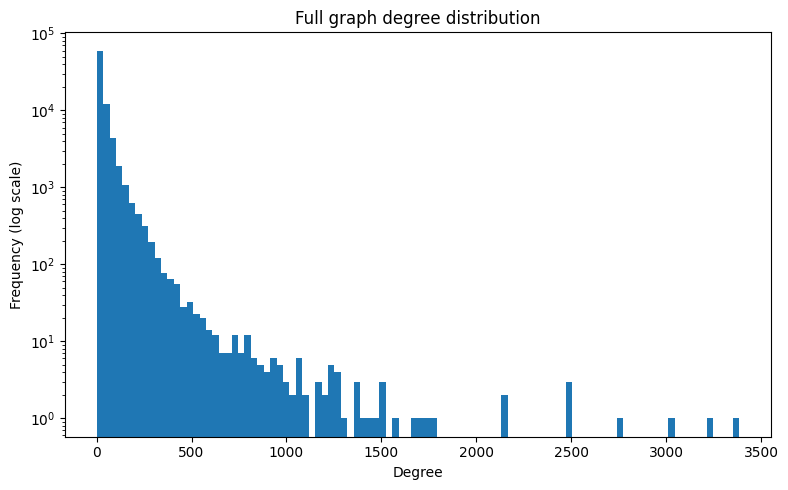

In [3]:
plt.figure(figsize=(8,5))
plt.hist(degrees, bins=100)
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Full graph degree distribution")
plt.tight_layout()
plt.show()


## 2. Connected 15,000-node experiment graph

A connected-growth sample is used because a random node-induced sample fragmented heavily on this dataset. This sampling choice is retained as an explicit limitation.


In [4]:
SAMPLE_SIZE = 15000
sampled_nodes = {random.choice(list(G.nodes()))}
frontier = set(G.neighbors(next(iter(sampled_nodes))))
while len(sampled_nodes) < SAMPLE_SIZE:
    if not frontier:
        raise RuntimeError("Frontier became empty before reaching sample size")
    node = random.choice(tuple(frontier))
    sampled_nodes.add(node)
    frontier.remove(node)
    frontier.update(n for n in G.neighbors(node) if n not in sampled_nodes)

G_connected = G.subgraph(sampled_nodes).copy()
experiment_degrees = np.array([d for _,d in G_connected.degree()])
print(f"Nodes: {G_connected.number_of_nodes():,}")
print(f"Edges: {G_connected.number_of_edges():,}")
print(f"Connected: {nx.is_connected(G_connected)}")
print(f"Mean degree: {experiment_degrees.mean():.2f}")
print(f"Median degree: {np.median(experiment_degrees):.2f}")
print(f"Max degree: {experiment_degrees.max():,}")


Nodes: 15,000
Edges: 101,318
Connected: True
Mean degree: 13.51
Median degree: 7.00
Max degree: 938


## 3. Synthetic traffic and attack


In [5]:
TIMESTEPS = 50
TRAFFIC_MU = 10
TRAFFIC_SIGMA = 2

traffic = {}
for edge in G_connected.edges():
    traffic[edge] = np.random.normal(TRAFFIC_MU, TRAFFIC_SIGMA, TIMESTEPS)

vals = np.concatenate(list(traffic.values()))
print(f"Traffic series: {len(traffic):,}")
print(f"Observations: {len(vals):,}")
print(f"Observed mean: {vals.mean():.4f} (target {TRAFFIC_MU})")
print(f"Observed std: {vals.std():.4f} (target {TRAFFIC_SIGMA})")


Traffic series: 101,318
Observations: 5,065,900
Observed mean: 9.9997 (target 10)
Observed std: 2.0002 (target 2)


In [6]:
ATTACK_TARGETS = 5
ATTACK_STRENGTH = 40
ATTACK_DURATION = 8
ATTACK_START_MIN = 10
ATTACK_START_MAX = 30

attack_targets = sorted(G_connected.degree(), key=lambda x:x[1], reverse=True)[:ATTACK_TARGETS]
attack_nodes = [n for n,_ in attack_targets]
attack_edges = set()
for node in attack_nodes:
    attack_edges.update(tuple(sorted((node,n))) for n in G_connected.neighbors(node))

print("Attack targets:")
for i,(n,d) in enumerate(attack_targets,1): print(f"{i}. {n} | degree={d}")
print(f"Attack edges: {len(attack_edges):,}")
print(f"Attack surface: {100*len(attack_edges)/G_connected.number_of_edges():.2f}%")

# Clean controlled attack
traffic = {}
for edge in G_connected.edges():
    traffic[edge] = np.random.normal(TRAFFIC_MU, TRAFFIC_SIGMA, TIMESTEPS)

ATTACK_START = 26
ATTACK_END = ATTACK_START + ATTACK_DURATION
attack_loads = {}
for edge in attack_edges:
    key = tuple(sorted(edge))
    traffic_key = key if key in traffic else (key[1],key[0])
    loads = traffic[traffic_key].copy()
    for t in range(ATTACK_START, ATTACK_END):
        loads[t] += ATTACK_STRENGTH*np.random.uniform(0.7,1.2)
    traffic[traffic_key] = loads
    attack_loads[key] = loads

print(f"Attack window: t={ATTACK_START}..{ATTACK_END-1}")
print(f"Affected edges: {len(attack_loads):,}")


Attack targets:
1. 40981798 | degree=938
2. 43003845 | degree=806
3. 3359851 | degree=775
4. 22462180 | degree=721
5. 59804598 | degree=506
Attack edges: 3,740
Attack surface: 3.69%
Attack window: t=26..33
Affected edges: 3,740


## 4. Disorder metric and EARA weights


In [7]:
edge_disorder = {}
for edge,loads in traffic.items():
    variance = np.var(loads)
    temporal_change = np.mean(np.abs(np.diff(loads)))
    disorder = np.log(1 + variance + 0.5*temporal_change)
    edge_disorder[edge] = {"variance":variance,"temporal_change":temporal_change,"disorder":disorder}

BASELINE_WEIGHT = 1.0
MAX_WEIGHT = 5.0
weights = {edge:min(BASELINE_WEIGHT+v["disorder"],MAX_WEIGHT) for edge,v in edge_disorder.items()}
for edge,w in weights.items():
    G_connected[edge[0]][edge[1]]["weight"] = w

att = np.array([v["disorder"] for e,v in edge_disorder.items() if tuple(sorted(e)) in attack_edges])
unatt = np.array([v["disorder"] for e,v in edge_disorder.items() if tuple(sorted(e)) not in attack_edges])
print(f"Attacked disorder: mean={att.mean():.4f}, median={np.median(att):.4f}, range=({att.min():.4f},{att.max():.4f})")
print(f"Unaffected disorder: mean={unatt.mean():.4f}, median={np.median(unatt):.4f}, range=({unatt.min():.4f},{unatt.max():.4f})")
raw_w = np.array([BASELINE_WEIGHT+v["disorder"] for v in edge_disorder.values()])
cap_w = np.minimum(raw_w,MAX_WEIGHT)
print(f"Edges affected by cap: {(raw_w>MAX_WEIGHT).sum():,}")


Attacked disorder: mean=5.3248, median=5.3299, range=(4.9272,5.6352)
Unaffected disorder: mean=1.7888, median=1.7910, range=(1.1521,2.3678)
Edges affected by cap: 3,740


## 5. Baseline and capped EARA routing


In [8]:
NUM_ROUTES = 100
ROUTING_SEED = 42
rng = random.Random(ROUTING_SEED)
nodes = list(G_connected.nodes())
route_pairs = [tuple(rng.sample(nodes,2)) for _ in range(NUM_ROUTES)]

baseline_routes=[]
eara_routes=[]
for source,destination in route_pairs:
    bpath = nx.shortest_path(G_connected, source, destination)
    epath = nx.shortest_path(G_connected, source, destination, weight="weight")
    baseline_routes.append({"source":source,"destination":destination,"path":bpath,"length":len(bpath)-1})
    eara_routes.append({"source":source,"destination":destination,"path":epath,"length":len(epath)-1,"weighted_cost":nx.path_weight(G_connected,epath,weight="weight")})

print(f"Routes computed: {len(eara_routes)}")
for i,r in enumerate(eara_routes[:5],1):
    print(f"{i}. {r['source']} -> {r['destination']} | hops={r['length']} | weighted cost={r['weighted_cost']:.4f}")


Routes computed: 100
1. 33249457 -> 76091295 | hops=3 | weighted cost=8.2525
2. 16286650 -> 1173281 | hops=4 | weighted cost=11.1790
3. 47785747 -> 7054002 | hops=2 | weighted cost=5.7820
4. 7282592 -> 302191488 | hops=4 | weighted cost=10.8457
5. 77719141 -> 16846426 | hops=5 | weighted cost=13.5282


## 6. Primary evaluation


In [9]:
def count_attack_edges(path):
    return sum(tuple(sorted((u,v))) in attack_edges for u,v in zip(path[:-1],path[1:]))

baseline_lengths=np.array([r["length"] for r in baseline_routes])
eara_lengths=np.array([r["length"] for r in eara_routes])
rows=[]
for b,e in zip(baseline_routes,eara_routes):
    bc=nx.path_weight(G_connected,b["path"],weight="weight")
    ba=count_attack_edges(b["path"]); ea=count_attack_edges(e["path"])
    rows.append({"source":b["source"],"destination":b["destination"],"baseline_hops":b["length"],"eara_hops":e["length"],"baseline_weighted_cost":bc,"eara_weighted_cost":e["weighted_cost"],"baseline_attack_edges":ba,"eara_attack_edges":ea,"baseline_attack_fraction":ba/b["length"],"eara_attack_fraction":ea/e["length"]})
comparison_df=pd.DataFrame(rows)

print("Primary evaluation")
print("-"*65)
print(f"Mean hops: {baseline_lengths.mean():.2f} -> {eara_lengths.mean():.2f}")
print(f"Median hops: {np.median(baseline_lengths):.2f} -> {np.median(eara_lengths):.2f}")
print(f"Mean weighted cost: {comparison_df.baseline_weighted_cost.mean():.4f} -> {comparison_df.eara_weighted_cost.mean():.4f}")
print(f"Median weighted cost: {comparison_df.baseline_weighted_cost.median():.4f} -> {comparison_df.eara_weighted_cost.median():.4f}")
print(f"Attack-edge fraction: {comparison_df.baseline_attack_fraction.mean():.4f} -> {comparison_df.eara_attack_fraction.mean():.4f}")
print(f"Attack-edge traversals: {comparison_df.baseline_attack_edges.sum()} -> {comparison_df.eara_attack_edges.sum()}")
print(f"Routes using attack edges: {(comparison_df.baseline_attack_edges>0).sum()} -> {(comparison_df.eara_attack_edges>0).sum()}")


Primary evaluation
-----------------------------------------------------------------
Mean hops: 4.18 -> 4.26
Median hops: 4.00 -> 4.00
Mean weighted cost: 12.7910 -> 11.5779
Median weighted cost: 11.4431 -> 11.0649
Attack-edge fraction: 0.1165 -> 0.0000
Attack-edge traversals: 52 -> 0
Routes using attack edges: 23 -> 0


In [10]:
route_summary=pd.DataFrame({"metric":["Mean hops","Median hops","Mean weighted cost","Median weighted cost","Mean attack-edge fraction","Total attack-edge traversals","Routes using attack edges"],"baseline":[baseline_lengths.mean(),np.median(baseline_lengths),comparison_df.baseline_weighted_cost.mean(),comparison_df.baseline_weighted_cost.median(),comparison_df.baseline_attack_fraction.mean(),comparison_df.baseline_attack_edges.sum(),(comparison_df.baseline_attack_edges>0).sum()],"eara":[eara_lengths.mean(),np.median(eara_lengths),comparison_df.eara_weighted_cost.mean(),comparison_df.eara_weighted_cost.median(),comparison_df.eara_attack_fraction.mean(),comparison_df.eara_attack_edges.sum(),(comparison_df.eara_attack_edges>0).sum()]})
display(route_summary)


,metric,baseline,eara
0,Mean hops,4.180000,4.260000
1,Median hops,4.000000,4.000000
2,Mean weighted cost,12.791015,11.577882
3,Median weighted cost,11.443093,11.064866
4,Mean attack-edge fraction,0.116524,0.000000
5,Total attack-edge traversals,52.000000,0.000000
6,Routes using attack edges,23.000000,0.000000


## 7. Longer-path diagnostic


In [11]:
longer=comparison_df[comparison_df.eara_hops>comparison_df.baseline_hops].copy()
longer["hop_increase"]=longer.eara_hops-longer.baseline_hops
longer["cost_difference"]=longer.eara_weighted_cost-longer.baseline_weighted_cost
print(f"Affected routes: {len(longer)}")
print(f"Mean hop increase: {longer.hop_increase.mean():.2f}")
print(f"Mean weighted-cost reduction: {-longer.cost_difference.mean():.4f}")
print(f"Baseline attack edges/route: {longer.baseline_attack_edges.mean():.2f}")
print(f"EARA attack edges/route: {longer.eara_attack_edges.mean():.2f}")
display(longer[["source","destination","baseline_hops","eara_hops","baseline_attack_edges","eara_attack_edges","baseline_weighted_cost","eara_weighted_cost"]])


Affected routes: 6
Mean hop increase: 1.33
Mean weighted-cost reduction: 2.0934
Baseline attack edges/route: 2.33
EARA attack edges/route: 0.00


,source,destination,baseline_hops,eara_hops,baseline_attack_edges,eara_attack_edges,baseline_weighted_cost,eara_weighted_cost
25,113741392,15338794,3,4,2,0,12.909784,10.709286
31,23838767,545671773,5,6,2,0,18.302646,16.453463
34,77244813,128971757,4,6,3,0,17.665978,15.755960
53,189814803,8067082,4,5,2,0,15.582822,13.373445
77,322381069,15099871,5,6,2,0,18.705941,16.256297
83,423169271,16509213,4,6,3,0,17.992141,16.050584


## 8. Capped vs. uncapped EARA


In [12]:
uncapped_weights={edge:BASELINE_WEIGHT+v["disorder"] for edge,v in edge_disorder.items()}
for edge,w in uncapped_weights.items():
    G_connected[edge[0]][edge[1]]["uncapped_weight"]=w

eara_uncapped_routes=[]
for source,destination in route_pairs:
    path=nx.shortest_path(G_connected,source,destination,weight="uncapped_weight")
    eara_uncapped_routes.append({"source":source,"destination":destination,"path":path,"length":len(path)-1,"weighted_cost":nx.path_weight(G_connected,path,weight="uncapped_weight")})

cu=[]
for capped,uncapped in zip(eara_routes,eara_uncapped_routes):
    ca=count_attack_edges(capped["path"]); ua=count_attack_edges(uncapped["path"])
    cu.append({"source":capped["source"],"destination":capped["destination"],"capped_hops":capped["length"],"uncapped_hops":uncapped["length"],"capped_cost":capped["weighted_cost"],"uncapped_cost":uncapped["weighted_cost"],"capped_attack_edges":ca,"uncapped_attack_edges":ua,"same_path":capped["path"]==uncapped["path"]})
cu=pd.DataFrame(cu)
print(f"Same route: {cu.same_path.sum()} / {len(cu)}")
print(f"Different route: {(~cu.same_path).sum()} / {len(cu)}")
print(f"Mean hops capped/uncapped: {cu.capped_hops.mean():.2f} / {cu.uncapped_hops.mean():.2f}")
print(f"Attack-edge fraction capped: {(cu.capped_attack_edges/cu.capped_hops).mean():.4f}")
print(f"Attack-edge fraction uncapped: {(cu.uncapped_attack_edges/cu.uncapped_hops).mean():.4f}")


Same route: 100 / 100
Different route: 0 / 100
Mean hops capped/uncapped: 4.26 / 4.26
Attack-edge fraction capped: 0.0000
Attack-edge fraction uncapped: 0.0000


In [13]:
cross=[]
for c,u in zip(eara_routes,eara_uncapped_routes):
    cp,up=c["path"],u["path"]
    cross.append({"source":c["source"],"destination":c["destination"],"capped_path_capped_cost":nx.path_weight(G_connected,cp,weight="weight"),"uncapped_path_capped_cost":nx.path_weight(G_connected,up,weight="weight"),"capped_path_uncapped_cost":nx.path_weight(G_connected,cp,weight="uncapped_weight"),"uncapped_path_uncapped_cost":nx.path_weight(G_connected,up,weight="uncapped_weight"),"same_path":cp==up})
cross_df=pd.DataFrame(cross)
capped_opt=(cross_df.capped_path_capped_cost<=cross_df.uncapped_path_capped_cost)
uncapped_opt=(cross_df.uncapped_path_uncapped_cost<=cross_df.capped_path_uncapped_cost)
print(f"Capped-path cost under capped weights: {cross_df.capped_path_capped_cost.mean():.4f}")
print(f"Uncapped-path cost under capped weights: {cross_df.uncapped_path_capped_cost.mean():.4f}")
print(f"Capped-path cost under uncapped weights: {cross_df.capped_path_uncapped_cost.mean():.4f}")
print(f"Uncapped-path cost under uncapped weights: {cross_df.uncapped_path_uncapped_cost.mean():.4f}")
print(f"Capped optimal under capped objective: {capped_opt.sum()} / {len(cross_df)}")
print(f"Uncapped optimal under uncapped objective: {uncapped_opt.sum()} / {len(cross_df)}")


Capped-path cost under capped weights: 11.5779
Uncapped-path cost under capped weights: 11.5779
Capped-path cost under uncapped weights: 11.5779
Uncapped-path cost under uncapped weights: 11.5779
Capped optimal under capped objective: 100 / 100
Uncapped optimal under uncapped objective: 100 / 100


## 9. Variance-only diagnostic


In [14]:
variance_only={edge:np.log(1+v["variance"]) for edge,v in edge_disorder.items()}
cur=np.array([v["disorder"] for v in edge_disorder.values()])
vo=np.array(list(variance_only.values()))
diff=np.abs(cur-vo)
print(f"Mean current disorder: {cur.mean():.4f}")
print(f"Mean variance-only disorder: {vo.mean():.4f}")
print(f"Median current disorder: {np.median(cur):.4f}")
print(f"Median variance-only disorder: {np.median(vo):.4f}")
print(f"Mean absolute difference: {diff.mean():.4f}")
print(f"Maximum absolute difference: {diff.max():.4f}")


Mean current disorder: 1.9194
Mean variance-only disorder: 1.7186
Median current disorder: 1.7984
Median variance-only disorder: 1.5908
Mean absolute difference: 0.2008
Maximum absolute difference: 0.2971


## 10. Robustness across route seeds


In [15]:
ROUTE_SEEDS=[42,43,44,45,46]
rob=[]
nodes=list(G_connected.nodes())
for seed in ROUTE_SEEDS:
    rr=random.Random(seed)
    pairs=[tuple(rr.sample(nodes,2)) for _ in range(NUM_ROUTES)]
    bl=[]; el=[]; baf=[]; eaf=[]; bw=[]; ew=[]
    for s,d in pairs:
        bp=nx.shortest_path(G_connected,s,d)
        ep=nx.shortest_path(G_connected,s,d,weight="weight")
        bh=len(bp)-1; eh=len(ep)-1
        ba=count_attack_edges(bp); ea=count_attack_edges(ep)
        bl.append(bh); el.append(eh); baf.append(ba/bh); eaf.append(ea/eh)
        bw.append(nx.path_weight(G_connected,bp,weight="weight")); ew.append(nx.path_weight(G_connected,ep,weight="weight"))
    rob.append({"seed":seed,"baseline_hops":np.mean(bl),"eara_hops":np.mean(el),"baseline_attack_fraction":np.mean(baf),"eara_attack_fraction":np.mean(eaf),"baseline_weighted_cost":np.mean(bw),"eara_weighted_cost":np.mean(ew)})
robustness_df=pd.DataFrame(rob)
display(robustness_df)


,seed,baseline_hops,eara_hops,baseline_attack_fraction,eara_attack_fraction,baseline_weighted_cost,eara_weighted_cost
0,42,4.18,4.26,0.116524,0.000000,12.791015,11.577882
1,43,4.19,4.31,0.172167,0.014667,13.137125,11.853805
2,44,4.18,4.31,0.162333,0.027333,13.063334,11.868132
3,45,4.03,4.14,0.137714,0.014000,12.571416,11.391532
4,46,4.11,4.25,0.174833,0.009000,12.955803,11.604988


In [16]:
print("Robustness mean ± sample SD")
for col in robustness_df.columns[1:]:
    print(f"{col}: {robustness_df[col].mean():.4f} ± {robustness_df[col].std(ddof=1):.4f}")


Robustness mean ± sample SD
baseline_hops: 4.1380 ± 0.0683
eara_hops: 4.2540 ± 0.0695
baseline_attack_fraction: 0.1527 ± 0.0250
eara_attack_fraction: 0.0130 ± 0.0099
baseline_weighted_cost: 12.9037 ± 0.2268
eara_weighted_cost: 11.6593 ± 0.2017


## 11. Optional plots for the paper


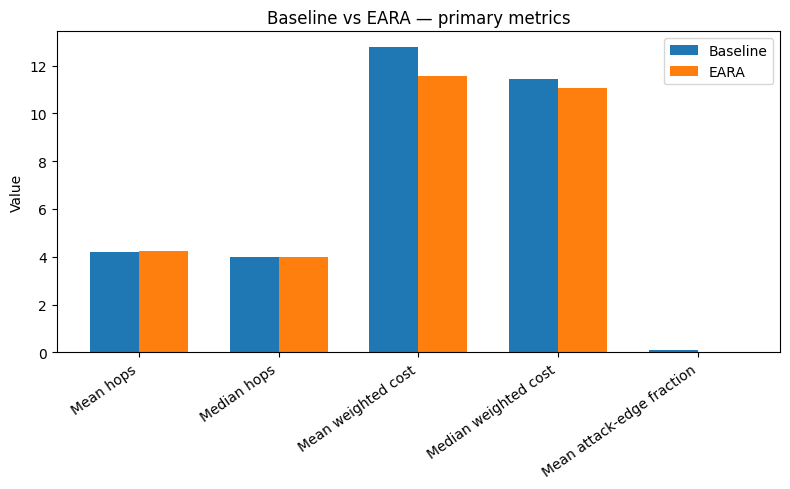

In [17]:
plot_df=route_summary.iloc[:5].copy()
fig,ax=plt.subplots(figsize=(8,5))
x=np.arange(len(plot_df))
w=0.35
ax.bar(x-w/2,plot_df.baseline,width=w,label="Baseline")
ax.bar(x+w/2,plot_df.eara,width=w,label="EARA")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.metric,rotation=35,ha="right")
ax.set_ylabel("Value")
ax.set_title("Baseline vs EARA — primary metrics")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Methodological notes for the conference paper

The notebook should not overstate the results. The primary experiment is attack-aware routing using disorder calculated from the observed post-attack traffic history. It is not, by itself, a demonstration of pre-attack prediction.

Other limitations to disclose: the connected-growth 15,000-node sample is not guaranteed to preserve the full graph distribution; the graph is represented as undirected; traffic is synthetic and independently generated per edge; the current implementation includes a temporal-change term in addition to variance; and the maximum weight cap collapses all sufficiently high-disorder edges to the same weight.
